In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv(
   r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day10_feature_engineeredv2.csv"
)

In [19]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup', 'MonthlyChargeGroup', 'RevenueSegment',
       'AvgRevenuePerMonth', 'ServiceCount', 'EngagementScore',
       'RevenueEfficiency', 'RiskSegment', 'MonthlyChargeCategory',
       'ContractSecurityScore', 'TotalServices'],
      dtype='str')

In [20]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [ ]:
#Convert Target Variable       #skip this step on runnning again day 11 if needed DONT RUN THIS AGAIN...
df["Churn"] = df["Churn"].map(
    {
        "No":0,
        "Yes":1
    }
)

In [21]:
#Separate Features and Target
X = df.drop(
    columns=["Churn"]
)

y = df["Churn"]

In [22]:
#Check Remaining Data Types
X.dtypes

customerID                   str
gender                       str
SeniorCitizen              int64
Partner                      str
Dependents                   str
tenure                   float64
PhoneService                 str
MultipleLines                str
InternetService              str
OnlineSecurity               str
OnlineBackup                 str
DeviceProtection             str
TechSupport                  str
StreamingTV                  str
StreamingMovies              str
Contract                     str
PaperlessBilling             str
PaymentMethod                str
MonthlyCharges           float64
TotalCharges             float64
TenureGroup                  str
MonthlyChargeGroup           str
RevenueSegment               str
AvgRevenuePerMonth       float64
ServiceCount               int64
EngagementScore          float64
RevenueEfficiency        float64
RiskSegment                  str
MonthlyChargeCategory        str
ContractSecurityScore      int64
TotalServi

In [23]:
#Logistic Regression cannot work with text/categorical values directly, you must encode these columns before training.
X = pd.get_dummies(
    X,
    drop_first=True
)

In [24]:
X.select_dtypes(include=["object", "string"]).columns

Index([], dtype='str')

In [26]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(5634, 7087)
(1409, 7087)
(5634,)
(1409,)


In [28]:
# Scale Features on traing data only
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_scaled[:5]

array([[-0.44177295,  0.10237124, -0.52197565, ..., -0.5766671 ,
         1.74070185, -0.58049289],
       [-0.44177295, -0.71174346,  0.33747781, ..., -0.5766671 ,
        -0.57448092, -0.58049289],
       [-0.44177295, -0.79315493, -0.80901319, ..., -0.5766671 ,
         1.74070185, -0.58049289],
       [-0.44177295, -0.26398038,  0.28438416, ..., -0.5766671 ,
        -0.57448092, -0.58049289],
       [-0.44177295, -1.28162375, -0.67627907, ..., -0.5766671 ,
         1.74070185, -0.58049289]], shape=(5, 7087))

In [ ]:
df.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day11_model_ready.csv",
    index=False
)



                                                            # DAY 12 #                                                      

In [ ]:
                                                            #DAY 12 TASKS
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

df = pd.read_csv(
   r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day11_model_ready.csv"
)

In [34]:
#Create / Initialize Logistic Regression Model
log_model = LogisticRegression(
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [35]:
#Generate Predictions
y_pred = log_model.predict(
    X_test_scaled
)

In [36]:
#Generate Probability Scores
y_prob = log_model.predict_proba(
    X_test_scaled
)[:,1]

In [37]:
#ACCURACY SCORES
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.7970191625266146


In [38]:
#CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[974  61]
 [225 149]]


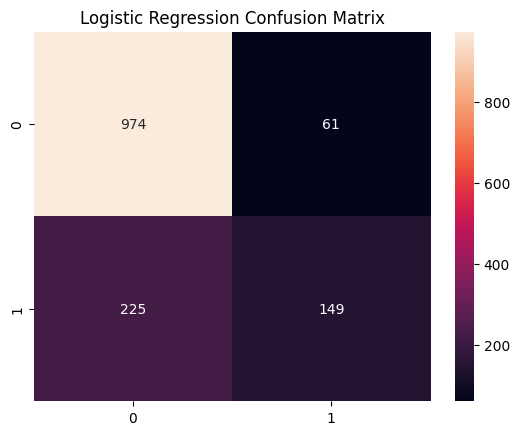

In [39]:
#CONFUSION MATRIX VISUALISATION
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [40]:
#ROC-AUC CURVE
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(roc_auc)

0.8413753907360045


In [41]:
#ROC CURVE
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

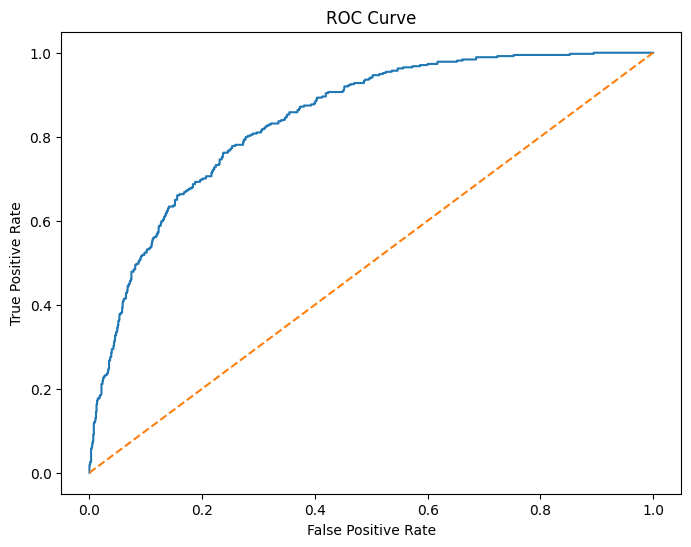

In [42]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [43]:
df.to_csv(
    r"C:\Users\user\OneDrive\Desktop\ZAALIMA PROJECT\CUSTOMER CHURN PREDICTION LTV ENGINE\data\processed\telco_churn_day11_model_ready.csv",
    index=False
)